<a href="https://colab.research.google.com/github/tigermorning/pose-image-tool/blob/main/pose_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pose-Controlled Image Generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tigermorning/pose-image-tool/blob/main/pose_tool.ipynb)

Generate images that follow **both** a reference pose and a text prompt.

**Pipeline:** reference photo -> OpenPose keypoints + MiDaS depth -> two hint images -> two ControlNets -> SDXL -> output image.

| | |
|---|---|
| Base model | `SG161222/RealVisXL_V5.0` - a photoreal SDXL fine-tune |
| ControlNet - pose | `thibaud/controlnet-openpose-sdxl-1.0` |
| ControlNet - depth | `diffusers/controlnet-depth-sdxl-1.0` |
| Annotators | `controlnet_aux` `OpenposeDetector` + `MidasDetector` (`lllyasviel/Annotators`) |
| GPU | Colab free **T4** is enough (fp16, ~10 GB peak). Placement adapts to the VRAM and RAM the notebook measures. |

**Before you start:** `Runtime > Change runtime type > T4 GPU`, and have 2 photos of people in clearly different poses ready to upload (section 3).

## How this notebook answers the assignment

| Assignment | Where | Output |
|---|---|---|
| **Step 1** - one reference photo, extract the pose, generate a *different person* in that same pose | section 5, prompt **A1** | `samples/output_01.png` |
| **Step 2a** - same pose, change only the prompt | section 5, **A1 vs A2** | `output_01.png`, `output_01_alt_prompt.png` |
| **Step 2b** - same prompt, change only the pose photo | section 5, **A1 on both hints** | `output_01.png`, `output_02.png` |
| **Step 2** write-up - what was changed, how the output changed | section 7, the final cell | - |

`output_01.png` and `output_02.png` share prompt and seed byte for byte and differ only in which
photograph the skeleton came from. That difference is the evidence the tool works, and it is why
step 1's output doubles as one arm of step 2b - there is nothing to generate twice.

Step 2b sends **A1 unchanged**, posture clauses included. Diagnostic 1 shows why that is safe: a
posture clause that contradicts the hint is discarded rather than blended, so the prompt can stay
byte-identical to step 1's, which is what the assignment asks for.

**Sections:** 1 Install dependencies - 2 Load models - 3 Extract pose - 4 Generate image - 5 Experiments - 6 Save results - 7 Findings

---
## 1. Install dependencies

In [1]:
# Install the diffusion stack and the OpenPose annotator.
# controlnet_aux is pinned to 0.0.10: 0.0.9 constrains timm so tightly that pip cannot resolve it.
# Do NOT add mediapipe. controlnet_aux imports it at package level and against Colab's build that
# raises `AttributeError: module 'mediapipe' has no attribute 'solutions'`, which breaks the import
# of OpenposeDetector itself. Uninstalled, it only prints a warning and everything works.
!pip install -q "diffusers>=0.31" "transformers>=4.44" "accelerate>=0.34" safetensors
!pip install -q "controlnet_aux==0.0.10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 9.1 MB/s eta 0:00:00


In [2]:
# Confirm a CUDA GPU is attached, then measure BOTH memory ceilings before anything loads.
# Colab enforces them separately and they fail differently: exhausting system RAM kills the
# session outright, exhausting VRAM raises CUDA out of memory. The placement decision in the
# next cell reads these numbers, so they are measured rather than assumed.
import platform
import shutil

import torch

assert torch.cuda.is_available(), 'No GPU attached. Colab: Runtime > Change runtime type > T4 GPU.'
_props = torch.cuda.get_device_properties(0)
FREE_VRAM_GB, TOTAL_VRAM_GB = (b / 1024 ** 3 for b in torch.cuda.mem_get_info())

try:
    import psutil

    FREE_RAM_GB = psutil.virtual_memory().available / 1024 ** 3
    TOTAL_RAM_GB = psutil.virtual_memory().total / 1024 ** 3
except ImportError:              # psutil ships with Colab, but do not hard-fail without it
    FREE_RAM_GB = TOTAL_RAM_GB = float('nan')

print(f'python : {platform.python_version()}')
print(f'torch  : {torch.__version__}')
print(f'gpu    : {_props.name}')
print(f'vram   : {FREE_VRAM_GB:.1f} GB free of {TOTAL_VRAM_GB:.1f} GB')
print(f'ram    : {FREE_RAM_GB:.1f} GB free of {TOTAL_RAM_GB:.1f} GB')
print(f'disk   : {shutil.disk_usage(".").free / 1024 ** 3:.1f} GB free')

# T4 has no usable bf16 path, so fp16 is used for every module in this notebook.
DTYPE = torch.float16

python : 3.12.13
torch  : 2.11.0+cu128
gpu    : Tesla T4
vram   : 14.5 GB free of 14.6 GB
ram    : 10.9 GB free of 12.7 GB
disk   : 65.9 GB free


---
## 2. Load models

Three cells. The first two load models, the third decides where they live.

1. **OpenPose annotator** - finds human keypoints. It only *reads* images; it generates nothing.
2. **SDXL + ControlNet** - generates images. ControlNet is the adapter that injects the skeleton
   into every denoising step.
3. **Placement** - keeps everything on the GPU when it fits, and offloads only when it does not.

In [3]:
# MODEL LOAD 1 of 2 - the two annotators.
# Neither generates anything. They read the reference photo and produce the two hints:
# OpenPose gives joint coordinates, MiDaS gives a depth map.
import numpy as np
from controlnet_aux import MidasDetector, OpenposeDetector
# drawing helpers, used to render the skeleton at the exact generation resolution
from controlnet_aux.open_pose.util import draw_bodypose, draw_handpose

# Guarded so re-running this cell does not load a second copy alongside the first.
if 'openpose' not in globals():
    openpose = OpenposeDetector.from_pretrained('lllyasviel/Annotators')
if 'midas' not in globals():
    midas = MidasDetector.from_pretrained('lllyasviel/Annotators')
print('annotators ready')

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

body_pose_model.pth: reconstructing file:   0%|          |  0.00B /  209MB            

body_pose_model.pth: downloading bytes:           |  0.00B            

hand_pose_model.pth: reconstructing file:   0%|          |  0.00B /  147MB            

hand_pose_model.pth: downloading bytes:           |  0.00B            

...

facenet.pth: downloading bytes:           |  0.00B            

dpt_hybrid-midas-501f0c75.pt: reconstructing file:   0%|          |  0.00B /  493MB            

dpt_hybrid-midas-501f0c75.pt: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


annotators ready


In [4]:
# MODEL LOAD 2 of 2 - the image generator.
# Three pieces: a photoreal SDXL checkpoint, and TWO ControlNets that steer it together.
#
#   pose  - an OpenPose skeleton. Says where the joints are.
#   depth - a depth map. Says which way the torso leans, what the body rests on, how the limbs
#           sit in space. A skeleton carries none of that, and this pose depends on it.
#
# The base is RealVisXL rather than SDXL base 1.0. Measured on this reference: base 1.0 rendered
# faces and skin that read as a mannequin, and no prompt or sampler setting fixed it, because it
# is the checkpoint's own character. Swapping the checkpoint did fix it.
#
# EACH PIECE MOVES TO THE GPU AS IT LOADS, and on a free T4 that ordering is what makes the
# notebook run at all. Loading all three first and calling .to('cuda') afterwards killed the
# kernel: the pose ControlNet ships as a 5 GB fp32 `.bin`, and pickle cannot be memory-mapped
# the way safetensors can, so torch.load holds the whole file in system RAM before the fp16
# cast. Stacked with the depth ControlNet and the UNet that peaks near 12 GB against this
# runtime's 12.7 GB ceiling, and Colab kills the session instead of raising an error. Handing
# each piece to the GPU as it arrives keeps the system-RAM peak at the size of the largest
# single component rather than their sum - measured here: 8.0 GB free before, 1.7 GB after.
import gc

import psutil
from diffusers import AutoencoderKL, ControlNetModel, StableDiffusionXLControlNetPipeline

BASE_ID = 'SG161222/RealVisXL_V5.0'
POSE_CN_ID = 'thibaud/controlnet-openpose-sdxl-1.0'
DEPTH_CN_ID = 'diffusers/controlnet-depth-sdxl-1.0'


def _ram(step):
    """Print the system-RAM headroom left, so a near-miss is visible instead of silent."""
    gc.collect()
    free = psutil.virtual_memory().available / 1024 ** 3
    print(f'  {step:<28s} RAM {free:5.1f} GB free, VRAM '
          f'{torch.cuda.memory_allocated() / 1024 ** 3:4.1f} GB held')


if 'pipe' in globals():
    print('pipeline already loaded - skipping')
else:
    _ram('before any load')
    pose_cn = ControlNetModel.from_pretrained(POSE_CN_ID, torch_dtype=DTYPE).to('cuda')
    _ram('pose ControlNet on GPU')
    depth_cn = ControlNetModel.from_pretrained(DEPTH_CN_ID, torch_dtype=DTYPE).to('cuda')
    _ram('depth ControlNet on GPU')
    vae = AutoencoderKL.from_pretrained('madebyollin/sdxl-vae-fp16-fix', torch_dtype=DTYPE).to('cuda')
    _ram('VAE on GPU')
    pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
        BASE_ID,
        controlnet=[pose_cn, depth_cn],
        vae=vae,
        torch_dtype=DTYPE,
        use_safetensors=True,
    )
    _ram('UNet + text encoders loaded')
    print('models loaded, ControlNets and VAE already on the GPU')

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


  before any load              RAM   7.8 GB free, VRAM  0.0 GB held


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

An error occurred while trying to fetch thibaud/controlnet-openpose-sdxl-1.0: thibaud/controlnet-openpose-sdxl-1.0 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  UNet + text encoders loaded  RAM   1.3 GB free, VRAM  4.9 GB held
models loaded, ControlNets and VAE already on the GPU


In [5]:
# DECIDE WHERE THE MODELS LIVE, from the memory measured in section 1.
# The trap worth knowing: offloading trades VRAM for system RAM, so on a RAM-limited machine it
# makes the more dangerous failure - the one that kills the session outright - more likely rather
# than less. A 15 GB T4 holds the whole pipeline, so there the fast path is also the safe one.
import gc

# Rough fp16 footprint at 832x1216: UNet ~5.1 GB, TWO ControlNets ~5.0 GB, text encoders
# ~1.5 GB, VAE ~0.2 GB, plus activations. 13 GB is that total with headroom.
VRAM_NEEDED_GB = 13.0
RAM_NEEDED_FOR_OFFLOAD_GB = 8.0

if FREE_VRAM_GB >= VRAM_NEEDED_GB:
    pipe.to('cuda')
    placement = f'full GPU ({FREE_VRAM_GB:.1f} GB VRAM free, nothing held in system RAM)'
elif FREE_RAM_GB >= RAM_NEEDED_FOR_OFFLOAD_GB:
    # Whole modules move to the GPU as each is called, then back. Slower than resident, but far
    # faster than sequential offload, which the diffusers docs call extremely slow.
    pipe.enable_model_cpu_offload()
    pipe.enable_vae_tiling()       # decodes the latent in overlapping tiles: lowers peak VRAM
    placement = f'model CPU offload ({FREE_VRAM_GB:.1f} GB VRAM, {FREE_RAM_GB:.1f} GB RAM free)'
else:
    # Both ceilings are tight. Sequential offload moves submodules rather than whole models: the
    # smallest VRAM footprint available, and by far the slowest.
    pipe.enable_sequential_cpu_offload()
    pipe.enable_vae_tiling()
    placement = 'sequential CPU offload - LAST RESORT, expect minutes per image'

# No enable_vae_slicing() here on purpose. Slicing splits a *batch* of latents, and the diffusers
# docs state there is no performance impact for single-image batches, which is all this notebook
# generates. Tiling is the setting that lowers peak memory for one large image.
pipe.set_progress_bar_config(leave=False)
gc.collect()
torch.cuda.empty_cache()
print(f'pipeline ready - {placement}')

pipeline ready - full GPU (14.5 GB VRAM free, nothing held in system RAM)


---
## 3. Extract pose

Upload the reference photos, then convert each one into a skeleton image.

- **Experiment A** (same pose, different prompts) needs **1** reference.
- **Experiment B** (same prompt, different poses) needs **2+** references with visibly different poses.

Good references: one person, full body or at least head-to-knee, limbs not overlapping the torso. Crowds and heavy occlusion are where OpenPose fails.

In [6]:
# Upload the reference photos (jpg / png / webp). They are kept in ./references,
# and every artifact this notebook produces goes to ./samples.
from pathlib import Path

from PIL import Image, ImageOps

REF_DIR = Path('references')
OUT_DIR = Path('samples')
REF_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

try:
    from google.colab import files

    for fname, data in files.upload().items():
        (REF_DIR / fname).write_bytes(data)
except ImportError:
    print('Not running on Colab - copy your images into ./references by hand, then re-run this cell.')

SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp'}
REFS = sorted(p for p in REF_DIR.iterdir() if p.suffix.lower() in SUFFIXES)
assert REFS, 'No reference images found in ./references'
print(f'{len(REFS)} reference image(s):', [p.name for p in REFS])

Saving a_stool_seated.jpg to a_stool_seated.jpg
Saving b_standing_fists.jpg to b_standing_fists.jpg
2 reference image(s): ['a_stool_seated.jpg', 'b_standing_fists.jpg']


In [21]:
# Helpers. The ControlNet hint and the generated image must have identical dimensions,
# so every reference is cropped to one fixed portrait resolution up front.
WIDTH, HEIGHT = 832, 1216  # SDXL-native portrait ratio; lighter on a T4 than 1024x1024


def load_ref(path, width=WIDTH, height=HEIGHT):
    """Open a reference photo, apply its EXIF rotation, and letterbox it to the target ratio.

    Letterboxing, not centre-cropping. A crop silently removes whatever falls outside the target
    aspect ratio: on one of the references here it cut the left ankle out of frame, which cost a
    keypoint and disabled pose control for that leg. Padding keeps the whole body.
    """
    img = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    return ImageOps.pad(img, (width, height), method=Image.LANCZOS)

In [8]:
# THE POSE EXTRACTION STEP. Turns one reference photo into the two hints ControlNet reads.
def extract_hints(image, include_hand=True):
    """Return (skeleton, depth) for one reference, both at the generation resolution.

    The skeleton is drawn from keypoints rather than taken from OpenposeDetector.__call__, which
    renders at its own resolution and rescales - that blurs the stick figure and changes its
    aspect ratio, and a blurred hint made SDXL draw three legs earlier in this project.
    """
    width, height = image.size
    people = openpose.detect_poses(np.array(image), include_hand=include_hand, include_face=False)
    if not people:
        raise RuntimeError('OpenPose found no person in this image.')

    canvas = np.zeros((height, width, 3), dtype=np.uint8)
    person = people[0]
    canvas = draw_bodypose(canvas, person.body.keypoints)
    if include_hand:
        canvas = draw_handpose(canvas, person.left_hand)
        canvas = draw_handpose(canvas, person.right_hand)

    depth = midas(image, detect_resolution=512, image_resolution=min(image.size))
    depth = depth.convert('RGB').resize((width, height), Image.BICUBIC)
    return Image.fromarray(canvas), depth

In [9]:
# RUN THE EXTRACTION over every uploaded reference, and save both hints.
poses = []
for i, path in enumerate(REFS, start=1):
    ref = load_ref(path)
    skeleton, depth = extract_hints(ref)
    skeleton.save(OUT_DIR / f'pose_{i:02d}.png')
    depth.save(OUT_DIR / f'depth_{i:02d}.png')
    poses.append({'id': f'{i:02d}', 'source': path.name, 'ref': ref,
                  'pose': skeleton, 'depth': depth})

print('saved:', [f"pose_{p['id']}.png + depth_{p['id']}.png" for p in poses])

saved: ['pose_01.png + depth_01.png', 'pose_02.png + depth_02.png']


### 3a. Check the hints before generating

**Do not skip this.** An unclosed hip-to-ankle chain silently disables pose control for that limb, and nothing later in the run reports it.

In [10]:
# Check each hint NUMERICALLY before spending GPU time on it.
# A skeleton can look plausible and still be unusable: if a hip-to-ankle chain does not close,
# pose control over that limb is silently off and nothing later in the run will say so. Four of
# six candidate references for this notebook were rejected by exactly this check.
COCO18 = ['nose', 'neck', 'r_shoulder', 'r_elbow', 'r_wrist', 'l_shoulder', 'l_elbow', 'l_wrist',
          'r_hip', 'r_knee', 'r_ankle', 'l_hip', 'l_knee', 'l_ankle', 'r_eye', 'l_eye',
          'r_ear', 'l_ear']
CHAINS = {'right arm': (2, 3, 4), 'left arm': (5, 6, 7),
          'right leg': (8, 9, 10), 'left leg': (11, 12, 13)}


def validate_pose(image, label=''):
    """Print the keypoint count and any limb chain that failed to close."""
    people = openpose.detect_poses(np.array(image))
    if len(people) != 1:
        print(f'{label}: FAIL - {len(people)} people detected, this pipeline assumes exactly 1')
        return False

    keypoints = people[0].body.keypoints
    found = {i for i, kp in enumerate(keypoints) if kp is not None}
    broken = [name for name, chain in CHAINS.items() if not set(chain) <= found]

    print(f'{label}: {len(found)}/18 keypoints')
    if broken:
        missing = ', '.join(COCO18[i] for i in range(18) if i not in found)
        print(f'  INCOMPLETE: {", ".join(broken)}  (missing {missing})')
        print('  -> pose control is off for those limbs; replace this reference')
    else:
        print('  all four limb chains complete')
    return not broken


for entry in poses:
    entry['valid'] = validate_pose(entry['ref'], f"pose_{entry['id']} ({entry['source']})")

pose_01 (a_stool_seated.jpg): 18/18 keypoints
  all four limb chains complete
pose_02 (b_standing_fists.jpg): 18/18 keypoints
  all four limb chains complete


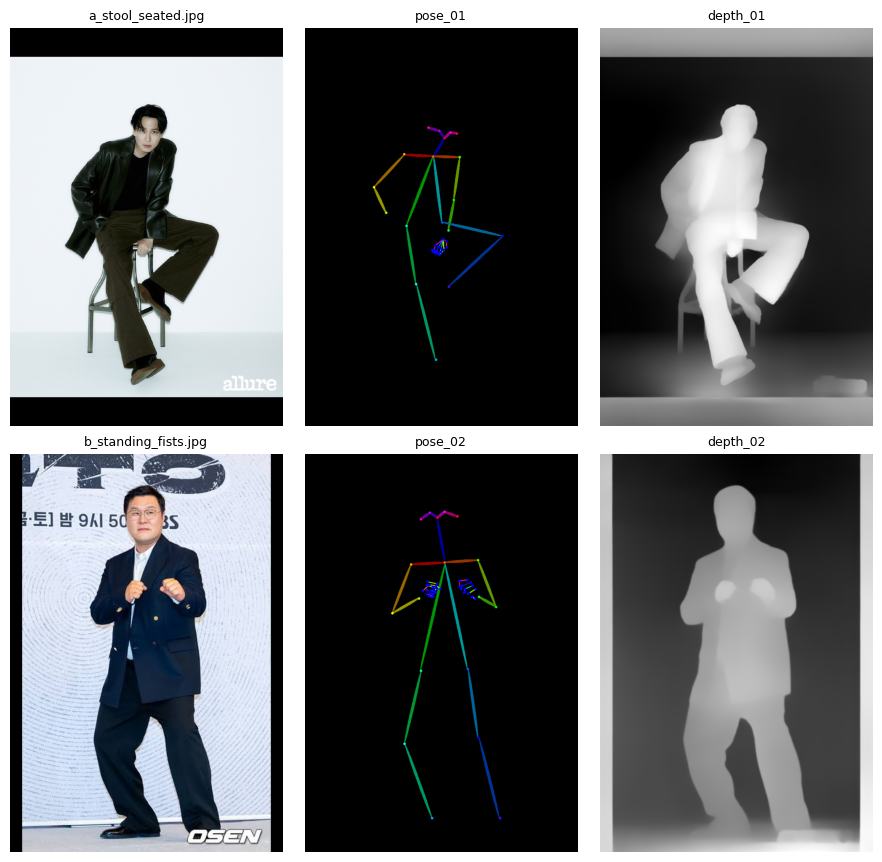

In [11]:
# Inspect every reference next to its skeleton. Do this before generating anything:
# a missing arm or a merged pair of legs here will be a missing arm in the output too.
import matplotlib.pyplot as plt
import numpy as np


def show_grid(images, titles, cols=None, size=3.0):
    """Display images in a labelled grid (used for every preview and experiment below)."""
    cols = cols or len(images)
    rows = -(-len(images) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * 1.45 * rows), squeeze=False)
    flat = axes.ravel()
    for ax, img, title in zip(flat, images, titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
    for ax in flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close(fig)   # otherwise every call leaves a figure open


show_grid(
    [im for p in poses for im in (p['ref'], p['pose'], p['depth'])],
    [t for p in poses for t in (p['source'], f"pose_{p['id']}", f"depth_{p['id']}")],
    cols=3,
)

---
## 4. Generate image

One helper does all generation. Every experiment below only changes its arguments, so the variable under test is always explicit.

Key knobs:

| Argument | Effect |
|---|---|
| `pose_scale` | How hard the skeleton is enforced. Low = prompt wins, high = pose wins but anatomy stiffens. |
| `depth_scale` | How hard the depth map is enforced. Carries torso lean, contact and limb ordering. |
| `guidance_scale` | How hard the text prompt is enforced. |
| `seed` | Fixed by default so experiments stay single-variable. |

The two scales are not equal. Pose defaults to **0.8** and depth to **0.6**: depth already pins the limbs, so giving pose full weight on top of it stiffens the body. **Diagnostic 2**, after the experiments, re-measures that against pose-only conditioning in this run rather than asking you to take it on trust. On a pose-only pipeline the opposite held - there 0.8 let a folded knee land 0.45 of the frame from the hint and 1.0 was required, which is a figure from a configuration this notebook no longer runs.

In [12]:
# THE IMAGE GENERATION STEP.
# Conditions on three things at once: the skeleton, the depth map, and the text prompt.
#
# The two conditioning scales are not equal. Pose is held slightly lower than depth would suggest
# because depth already pins the limbs; giving pose full weight on top of depth stiffens the body.
# Diagnostic 2, after the experiments, re-measures this against pose-only conditioning in the same
# run, so the justification is not a number carried in from somewhere else.
NEGATIVE = ('doll, mannequin, plastic skin, waxy, airbrushed, lowres, blurry, deformed hands, '
            'extra fingers, extra limbs, three legs, duplicated limbs, fused limbs, watermark, text')


def generate(hints, prompt, seed=1234, steps=28, guidance_scale=5.0,
             pose_scale=0.8, depth_scale=0.6, negative_prompt=NEGATIVE):
    """Return one image following the skeleton, the depth map and the prompt together.

    `hints` is the (skeleton, depth) pair from extract_hints(). The seed is explicit so any two
    calls can be compared as a controlled experiment.
    """
    torch.cuda.empty_cache()   # keep VRAM from fragmenting across a run
    skeleton, depth = hints
    return pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=[skeleton, depth],
        width=skeleton.width,
        height=skeleton.height,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        controlnet_conditioning_scale=[pose_scale, depth_scale],
        generator=torch.Generator('cuda').manual_seed(seed),
    ).images[0]

### 4a. Score the skeleton match

**Diagnostic, and narrower than it looks.** It compares joint coordinates only, so it catches scattered or duplicated limbs. Torso lean, what the hands are touching and where the weight sits are not in a skeleton and are not measured here - judge those by eye against the reference photograph.

In [13]:
# Score how closely the generated image's skeleton matches the hint.
#
# Read this number for what it is. It compares eighteen joint COORDINATES, so it catches limbs
# that scattered or duplicated. It cannot see which way the torso leans, what the hands are
# touching, or where the body's weight sits - none of that is in a skeleton. A generated image
# can score 0.02 here and still read as a different pose to a person. Use it to rule out tangled
# limbs, and judge the pose itself by eye against the reference photograph.
def pose_fidelity(hint_keypoints, image, label=''):
    """Report mean and max joint displacement between the hint and the generated image.

    Distances are normalised to the image (0.03 is a close match, 0.3 is a different pose).
    Only the limbs are scored; head keypoints follow the prompt more than the hint.
    """
    detected = openpose.detect_poses(np.array(image))
    if not detected:
        print(f'{label}: no person detected in the output')
        return None

    got = detected[0].body.keypoints
    scored, worst = [], ('', 0.0)
    for i in (2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13):
        a, b = hint_keypoints[i], got[i]
        if a is None or b is None:
            continue
        distance = ((a.x - b.x) ** 2 + (a.y - b.y) ** 2) ** 0.5
        scored.append(distance)
        if distance > worst[1]:
            worst = (COCO18[i], distance)
    if not scored:
        print(f'{label}: no comparable joints')
        return None
    mean = sum(scored) / len(scored)
    print(f'{label}: mean joint error {mean:.3f}, worst {worst[0]} {worst[1]:.3f} '
          f'({len(scored)} joints)')
    return mean


# Keypoints of each hint, kept so generated images can be scored against them.
for entry in poses:
    detected = openpose.detect_poses(np.array(entry['ref']))
    entry['keypoints'] = detected[0].body.keypoints if detected else None
print('hint keypoints stored for fidelity scoring')

hint keypoints stored for fidelity scoring


---
## 5. Experiments - the assignment's step 1 and step 2

Two runs, each isolating one variable. Prompt A1 doubles as step 1's deliverable: it is the
*different person in the reference's pose*. Prompts, seeds and settings are recorded in
`prompts.md`.

### Step 1 and Step 2a - same pose, different prompts

**A1 is step 1**: the reference is a seated man, and this prompt asks for a young African woman. Whatever posture survives comes from the skeleton alone, because the prompt never mentions one.

**A1 against A2 is step 2a**: the hint, the seed and every sampler setting are held fixed, so any difference between the two images is attributable to the prompt text and nothing else.

  0%|          | 0/28 [00:00<?, ?it/s]

A1: mean joint error 0.009, worst l_elbow 0.020 (12 joints)


  0%|          | 0/28 [00:00<?, ?it/s]

A2: mean joint error 0.013, worst r_wrist 0.029 (12 joints)


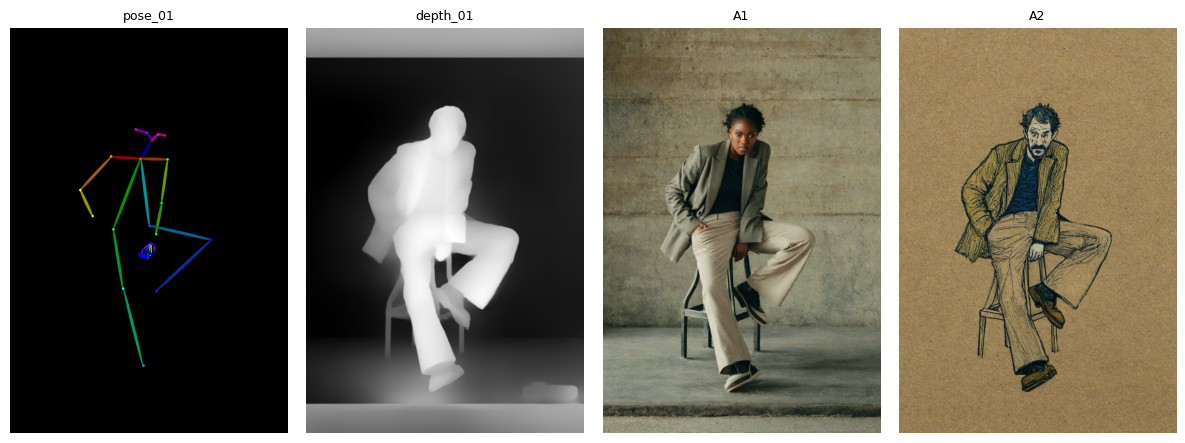

In [14]:
# EXPERIMENT A - one pose, two prompts, identical seed and sampler settings.
# A1 is the assignment's step 1: a different person in the reference's pose.
#
# Both prompts describe what the hints cannot: which way the torso leans, where the weight sits,
# what the hands are touching. The depth map carries much of this, the prompt reinforces it.
# What still must stay out of a prompt is anything the skeleton already fixes - limb angles.

HINTS_A = (poses[0]['pose'], poses[0]['depth'])
SEED = 1234                     # one seed throughout, so every comparison is single-variable
PROMPTS_A = [
    'A beautiful young African woman perched on the edge of a metal stool, leaning forward with her weight on her arm, one hand gripping the seat between her knees, wide dark trousers and a cropped jacket, sunlit concrete gallery, 85mm lens at f/2, candid editorial photograph, natural skin with visible pores',
    'An ink and watercolour drawing of a travelling puppeteer perched on the edge of a wooden stool, leaning forward with his weight on his arm, one hand gripping the seat between his knees, patched wool coat and worn boots, cream paper with visible fibres, loose brush strokes, ochre and burnt umber',
]

exp_a = []
for i, prompt in enumerate(PROMPTS_A, start=1):
    image = generate(HINTS_A, prompt, seed=SEED)
    exp_a.append(image)
    pose_fidelity(poses[0]['keypoints'], image, f'A{i}')

show_grid([poses[0]['pose'], poses[0]['depth'], *exp_a],
          [f"pose_{poses[0]['id']}", f"depth_{poses[0]['id']}", 'A1', 'A2'])

### Step 2b - same prompt, different pose photo

The prompt and the seed are fixed. The only thing that changes is which photograph the skeleton was
extracted from: `pose_01` (seated on a stool) or `pose_02` (standing, fists raised). This is the
inverse of step 2a.

The prompt is **A1 verbatim** - the same bytes as step 1, posture clauses and all. An earlier draft
stripped those clauses first, reasoning that `perched on the edge of a metal stool` would fight a
standing hint. Measurement removed the reason: A1 unchanged over the standing hint scored *better*
than the stripped version, and no stool appeared. Diagnostic 1 re-runs that comparison every time.

Because A1 on `pose_01` is exactly `output_01`, this step generates one image, not two.

  0%|          | 0/28 [00:00<?, ?it/s]

A1 on pose_02: mean joint error 0.008, worst l_wrist 0.014 (12 joints)


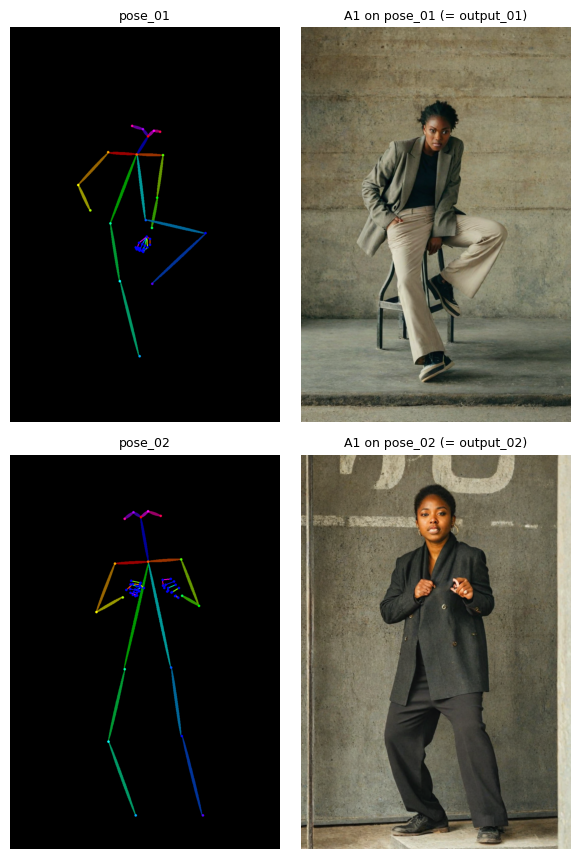

In [15]:
# EXPERIMENT B - one prompt, two references, identical seed and sampler settings.
# The assignment's step 2: the SAME prompt as step 1, byte for byte, over a different pose photo.
#
# A1 goes to pose_02 unchanged, posture clauses and all. An earlier draft of this notebook stripped
# those clauses first, on the reasoning that `perched on the edge of a metal stool` would fight a
# standing hint. Measurement removed that reasoning: A1 unchanged over the standing hint scored
# BETTER than the stripped version on the same hint, and no stool appeared. The clauses are
# discarded by the model rather than blended, so keeping them costs nothing and keeps the prompt
# byte-identical to step 1 - which is what the assignment actually asks for.
#
# The pose_01 arm of this comparison is output_01 itself: same prompt, same seed, same settings.
# It is not generated twice.
assert len(poses) >= 2, 'Upload at least two references with different poses to run experiment B.'

exp_b = generate((poses[1]['pose'], poses[1]['depth']), PROMPTS_A[0], seed=SEED)
pose_fidelity(poses[1]['keypoints'], exp_b, "A1 on pose_02")

show_grid([poses[0]['pose'], exp_a[0], poses[1]['pose'], exp_b],
          [f"pose_{poses[0]['id']}", 'A1 on pose_01 (= output_01)',
           f"pose_{poses[1]['id']}", 'A1 on pose_02 (= output_02)'],
          cols=2)

### Diagnostics - the controls section 7 argues from

Neither of these is a deliverable, and neither is saved to `samples/`. They exist because section 7
makes claims that would otherwise rest on numbers measured somewhere else, on different
hardware or on a pipeline this notebook no longer runs. Both are re-measured here, in this run, on
this GPU, so every figure quoted in the write-up comes from one place.

1. **A posture clause that contradicts the hint is dropped, not blended.** A1 describes `pose_01`
   (`perched on the edge of a metal stool`). Sent unchanged to the standing `pose_02`, does the
   pose degrade? Compare against `B on pose_02`, which is the same hint with the posture clauses
   removed.
2. **Pose 0.8 with depth 0.6 beats pose alone at 1.0.** Setting `depth_scale=0.0` disables the
   depth ControlNet's contribution, leaving pose-only conditioning. Compare against `A1`, which is
   the same prompt, hint and seed at the notebook's defaults.

A1 66 /77   pose-free 40 /77


  0%|          | 0/28 [00:00<?, ?it/s]

pose-free prompt on pose_02: mean joint error 0.010, worst l_wrist 0.016 (12 joints)


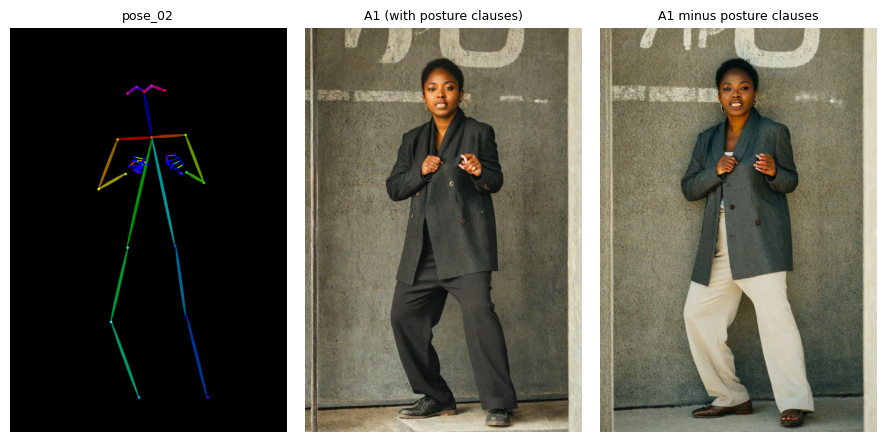


If these two score alike and neither shows a stool, the posture clauses were ignored, and
a prompt that fits only one of the two hints is safe to reuse across both.


In [16]:
# DIAGNOSTIC 1 - do the posture clauses in A1 do anything on a hint they contradict?
# A1 minus its three posture clauses, over the same standing hint. If the clauses were being
# honoured, removing them would change the result. Not saved: this is a control.
PROMPT_POSE_FREE = ('A beautiful young African woman, wide dark trousers and a cropped jacket, '
                    'sunlit concrete gallery, '
                    '85mm lens at f/2, candid editorial photograph, natural skin with visible pores')
print('A1', len(pipe.tokenizer(PROMPTS_A[0]).input_ids), '/77   pose-free',
      len(pipe.tokenizer(PROMPT_POSE_FREE).input_ids), '/77')

diag_posefree = generate((poses[1]['pose'], poses[1]['depth']), PROMPT_POSE_FREE, seed=SEED)
score_posefree = pose_fidelity(poses[1]['keypoints'], diag_posefree, 'pose-free prompt on pose_02')

show_grid([poses[1]['pose'], exp_b, diag_posefree],
          [f"pose_{poses[1]['id']}", 'A1 (with posture clauses)', 'A1 minus posture clauses'])
print()
print('If these two score alike and neither shows a stool, the posture clauses were ignored, and')
print('a prompt that fits only one of the two hints is safe to reuse across both.')

  0%|          | 0/28 [00:00<?, ?it/s]

A1 pose-only at 1.0: mean joint error 0.027, worst r_knee 0.065 (12 joints)


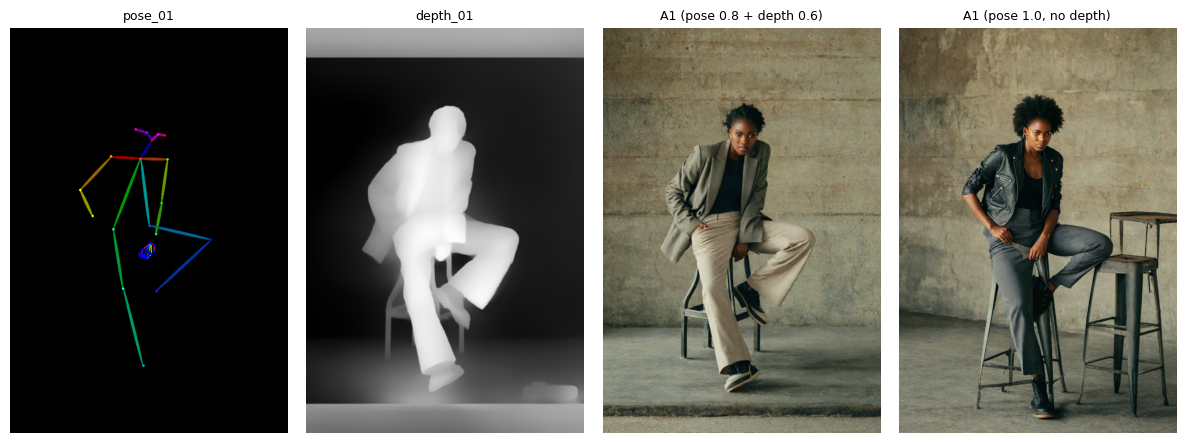


The joint score only compares coordinates. Depth carries lean, contact and limb ordering,
so also check whether the figure still rests on the stool rather than floating in front of it.


In [17]:
# DIAGNOSTIC 2 - is pose 0.8 + depth 0.6 actually better than pose alone at 1.0?
# depth_scale=0.0 zeroes the depth ControlNet's residuals, leaving pose-only conditioning.
# Everything else - prompt, hint, seed, steps, guidance - is held. Not saved: a control.
diag_pose_only = generate(HINTS_A, PROMPTS_A[0], seed=SEED, pose_scale=1.0, depth_scale=0.0)
score_pose_only = pose_fidelity(poses[0]['keypoints'], diag_pose_only, 'A1 pose-only at 1.0')

show_grid([poses[0]['pose'], poses[0]['depth'], exp_a[0], diag_pose_only],
          [f"pose_{poses[0]['id']}", f"depth_{poses[0]['id']}",
           'A1 (pose 0.8 + depth 0.6)', 'A1 (pose 1.0, no depth)'])
print()
print('The joint score only compares coordinates. Depth carries lean, contact and limb ordering,')
print('so also check whether the figure still rests on the stool rather than floating in front of it.')

### Diagnostic 3 - where the eyes are actually looking

`pose_fidelity()` scores twelve limb joints and is blind to the face. That blindness hid a real
defect: the head follows the hint and faces forward, while the irises sit off to one side, so the
face reads as glancing away. Judging that by eye is unreliable - a first pass at fixing it looked
better and measured worse - so it gets a number.

The metric takes the two eye keypoints, crops a window scaled to the face rather than to a fixed
pixel size, takes the darkest twelfth of each window as the pupil, and reports how far that
centroid sits from the window centre. Zero is centred. Both eyes agreeing on a sign is a real
gaze deviation rather than noise.

It also prints the one number that explains the whole failure: how many pixels apart the eyes are.

In [18]:
# DIAGNOSTIC 3 - gaze direction, measured rather than judged by eye.
def gaze_offset(image, label=''):
    """Report iris displacement from eye centre, and the eye scale that bounds what is possible."""
    people = openpose.detect_poses(np.array(image))
    if not people:
        print(f'{label}: no person detected')
        return None
    kp = people[0].body.keypoints
    r_eye, l_eye = kp[14], kp[15]
    if not (r_eye and l_eye):
        print(f'{label}: eye keypoints missing - nothing to measure')
        return None

    w, h = image.size
    rx, ry, lx, ly = r_eye.x * w, r_eye.y * h, l_eye.x * w, l_eye.y * h
    span = abs(lx - rx)
    grey = np.asarray(image.convert('L'), dtype=float)
    half_w, half_h = span * 0.42, span * 0.26   # window follows the face, not a fixed size

    offsets = []
    for cx, cy in ((rx, ry), (lx, ly)):
        x0, x1 = int(cx - half_w), int(cx + half_w)
        y0, y1 = int(cy - half_h), int(cy + half_h)
        win = grey[max(0, y0):y1, max(0, x0):x1]
        if win.size < 20:
            return None
        xs = np.nonzero(win <= np.percentile(win, 12))[1]
        offsets.append((xs.mean() - (win.shape[1] - 1) / 2) / win.shape[1])

    mean = sum(offsets) / len(offsets)
    print(f'{label}: iris offset R {offsets[0]:+.3f}  L {offsets[1]:+.3f}  mean {mean:+.3f}'
          f'   (0 = centred)')
    print(f'    eye span {span:.0f} px, window {int(2 * half_w)}x{int(2 * half_h)} px'
          f'  -> an iris is roughly {span / 5:.0f} px across')
    return mean


for img, label in ((exp_a[0], 'output_01 (A1)'),
                   (exp_b, 'output_02 (A1 on pose_02)'),
                   (diag_posefree, 'pose-free prompt on pose_02')):
    gaze_offset(img, label)

print()
print('The eye span is the finding. At this framing an iris spans single-digit pixels, which is')
print('below the size at which prompt text steers anything - the same reason fingers come out')
print('merged. Section 7 records how far prompt control reaches, and where it stops.')

output_01 (A1): iris offset R +0.095  L +0.097  mean +0.096   (0 = centred)
    eye span 33 px, window 27x17 px  -> an iris is roughly 7 px across
output_02 (A1 on pose_02): iris offset R -0.186  L +0.106  mean -0.040   (0 = centred)
    eye span 45 px, window 37x23 px  -> an iris is roughly 9 px across
pose-free prompt on pose_02: iris offset R -0.166  L +0.161  mean -0.003   (0 = centred)
    eye span 43 px, window 36x22 px  -> an iris is roughly 9 px across

The eye span is the finding. At this framing an iris spans single-digit pixels, which is
below the size at which prompt text steers anything - the same reason fingers come out
merged. Section 7 records how far prompt control reaches, and where it stops.


---
## 6. Save results

Writes the four filenames the repository expects, then zips `samples/` for download so the images can be committed.

In [19]:
# THE RESULT SAVING STEP.
# Three generated images, named for the assignment step each answers. The skeletons and depth maps
# were saved in section 3.
#
# There is no separate file for "A1 on pose_01" in step 2b, because that IS output_01 - same
# prompt, same seed, same settings. Step 2b is output_01 against output_02.
import shutil

exp_a[0].save(OUT_DIR / 'output_01.png')             # step 1: a different person, the reference pose
exp_a[1].save(OUT_DIR / 'output_01_alt_prompt.png')  # step 2a: same hint, the other prompt
exp_b.save(OUT_DIR / 'output_02.png')                # step 2b: same prompt, the other hint

shutil.make_archive('samples', 'zip', root_dir='.', base_dir='samples')  # cross-platform, no shell
print('samples/:', sorted(p.name for p in OUT_DIR.iterdir()))

# What the run actually cost, so the next person knows whether they had headroom.
print(f'peak VRAM: {torch.cuda.max_memory_allocated() / 1024 ** 3:.1f} GB')
try:
    import psutil

    print(f'RAM still free: {psutil.virtual_memory().available / 1024 ** 3:.1f} GB')
except ImportError:
    pass

try:
    from google.colab import files as colab_files

    colab_files.download('samples.zip')
except ImportError:
    print('samples.zip written next to the notebook')

samples/: ['depth_01.png', 'depth_02.png', 'output_01.png', 'output_01_alt_prompt.png', 'output_02.png', 'pose_01.png', 'pose_02.png']
peak VRAM: 13.8 GB
RAM still free: 1.4 GB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 7. Findings - what was changed, and how the output changed

Every figure below is printed by the cells above. The committed images in `samples/` come from one
run of this notebook on a free Colab T4, and that run's output is stored in the cells above. Full
GPU placement, peak VRAM 13.8 GB of 14.6 GB. Both references passed section 3a at 18/18 keypoints
with all four limb chains closed.

### What was changed

| Run | Held fixed | Varied | Output |
|---|---|---|---|
| **Step 1** | - | one reference, one prompt | `output_01.png` |
| **Step 2a** | hint `pose_01`, seed, steps, guidance, both conditioning scales | the prompt: photographic (A1) then ink-and-watercolour (A2) | `output_01_alt_prompt.png` |
| **Step 2b** | the prompt (A1, byte for byte), seed, every sampler setting | the hint: `pose_01` seated, `pose_02` standing | `output_02.png` |
| **Diagnostic 1** | hint `pose_02`, seed, settings | posture clauses in the prompt, present or stripped | not saved |
| **Diagnostic 2** | prompt A1, hint `pose_01`, seed | depth conditioning, 0.6 or off | not saved |
| **Diagnostic 3** | - | nothing - it measures gaze | not saved |

### How the output changed

| Output | Mean joint error | Worst joint |
|---|---|---|
| `output_01.png` - step 1 | **0.009** | l_elbow 0.020 |
| `output_01_alt_prompt.png` - step 2a | **0.013** | r_wrist 0.029 |
| `output_02.png` - step 2b | **0.008** | l_wrist 0.014 |
| diagnostic 1 - pose-free prompt on `pose_02` | 0.010 | l_wrist 0.016 |
| diagnostic 2 - pose alone at 1.0, no depth | **0.027** | r_knee 0.065 |

**Step 1 worked.** Every one of the twelve limb joints sits within 0.020 of the hint - one leg
extended to the floor, the other knee raised, the torso leaning forward off the stool - and the
subject is a different person from the reference. That is what the assignment asks for.

**Changing only the prompt rewrote everything except the posture.** A1 and A2 share hint, seed and
every sampler setting. Person, wardrobe, setting, palette and medium all changed; the posture held
at 0.013 even though A2 leaves photography for ink and watercolour.

**Changing only the pose photo rewrote the posture.** `output_01.png` and `output_02.png` were made
from a byte-identical prompt and seed, so the difference between them is attributable to the hint
alone. Subject, garment type and setting carried across; posture followed the photograph.

**Which change matters more.** The prompt rewrote the whole image except the posture; the hint
rewrote the posture. **The hint owns where the body is, the prompt owns what the body is.**

That is a tendency rather than a clean split. On an earlier pair the same prompt over two hints gave
jacket luma 109.3 against 70.2 - a 39-point difference out of 255 with nothing but the hint changed -
and the gap was widest when the prompt was shortest. A hint carries brightness and contact geometry
in alongside the pose; the depth map putting a stool under a prompt that never mentions one is the
same effect. **The weaker the prompt's specification, the more the hint decides.**

### Depth conditioning is the single largest factor

Diagnostic 2 removes it and nothing else: 0.009 becomes **0.027**, and the worst joint goes from
0.020 to 0.065. No other setting tested here moves the number that far.

The reason is what a skeleton omits. Eighteen joint coordinates fix where the limbs are and say
nothing about which way the torso leans, what the body rests on, or which limb is nearer the camera.
With that free the model invents it, and a figure whose joints all match the hint can still read as a
different pose. This also reverses an earlier conclusion: on a pose-only pipeline this project
measured that conditioning had to be 1.0, because at 0.8 a folded knee left the hint by 0.448 of the
frame. With depth carrying the limbs, full weight on pose stiffens the body instead. **The right
conditioning scale is a property of the hint set, not of the ControlNet.**

### A posture clause that fights the hint is dropped, not blended

A1 describes `pose_01` specifically - `perched on the edge of a metal stool`. Step 2b sends it
unchanged to the standing hint, and diagnostic 1 runs the same hint with those clauses stripped out.
No stool appears either way and the scores are alike - in fact A1 unchanged scored **0.008**
against **0.010** for the stripped prompt, so the contradiction cost nothing at all. The skeleton wins the contradiction outright, which is
what makes it safe to hold the prompt byte-identical across both hints - and holding it identical is
what step 2 asks for.

### What did not work

The pose side did not fail once. Everything that failed is on the prompt side, and most of it has one
cause: **the feature is too small in the frame for prompt text to reach.**

Measured on `output_01.png`:

| Feature | Size in frame | Outcome |
|---|---|---|
| Eyes, centre to centre | **33 px** | an iris spans about 7 px |
| Eyes on `output_02` | 45 px | an iris spans about 9 px |
| The supporting hand | **~54 px** | fingers merge into one mass |

- **Gaze.** The head faces forward because the hint says so - in the reference the nose sits within
  0.008 of both the eye midpoint and the ear midpoint, with both ears detected. The irises still sit
  off to one side, so the face reads as glancing away. Two fixes were tried and **both made it
  worse**: adding `looking straight into the lens` plus a poised-expression clause moved the iris
  offset from +0.108 to +0.157, with `averted eyes, cross-eyed, blank stare` and five more terms in
  the negative prompt at the same time. Diagnostic 3 exists because the first attempt *looked*
  better and *measured* worse.
- **Hands.** Both hands are wrong - finger count and orientation on the supporting hand, a malformed
  mass on the hand at the hip. Nine inpainting attempts at 1024 were made on the supporting hand and
  none produced correct anatomy. Cropping tightly enough to resolve fingers left too little context
  and the surroundings were replaced; cropping loosely enough to keep context left the fingers near
  50 px, where they merge again. At 54 px there is no finger information in the source to refine, so
  the model invents anatomy unrelated to the original. **A hand this small is not a prompt problem or
  a mask problem; it is a resolution problem.** The real fixes are a hand-specific refiner such as
  MeshGraphormer depth plus a hand ControlNet, a reference framed closer, or a higher generation
  resolution - all outside this tool.
- **Footwear.** Nothing in the prompt names shoes, and the model invented a different one per foot: a
  thick platform sole on the standing foot, a thin low sneaker on the raised one. A skeleton says
  nothing about shoes, so if the prompt does not either, nothing keeps a pair together.
- **Garment cut and colour.** `cropped jacket` was ignored in every image on both machines, hip
  length every time. `wide dark trousers` is stranger: sampling the trousers, the `dark` held on one
  machine (luma 55-58) and was ignored on another (99) with an identical prompt, seed and settings.
  Which clauses land is not fixed even for one prompt.
- **The negative prompt suppresses, it does not guarantee.** `text` and `watermark` are both in it,
  and one background still came back carrying garbled lettering on a wall.

**What the score cannot see.** `pose_fidelity()` compares twelve limb joint *coordinates*. Fingers,
faces, hems and eye direction are not in it, so a mean error of 0.009 and a visibly wrong hand are
both true at once. That is the metric's scope, not a contradiction. Each limitation above was found
by looking, then turned into a number where a number could be built - and where one could not, it
says so.

**The gaze metric needs reading carefully.** Its mean is not the signal. One image scored -0.003
while each eye sat past 0.16 in *opposite* directions, and it looked fine. What the metric reliably
catches is the two eyes agreeing on a direction, which is what `output_01` did at +0.095 and +0.097.
`output_02` scored -0.040 with its eyes at -0.186 and +0.106 - opposite signs, and it looks fine. Disagreement usually means the darkest pixels are eye corners rather than displaced irises.

### Getting it to run at all

Two practical failures cost more time than any setting.

**The kernel died loading the models, with no error.** The pose ControlNet ships as a 5 GB fp32
`.bin`, and pickle cannot be memory-mapped the way safetensors can, so `torch.load` holds the whole
file in system RAM before the fp16 cast. Stacked with the depth ControlNet and the UNet, the peak
approached a free Colab runtime's 12.7 GB RAM ceiling and the session was killed rather than raising
an error. Section 2 now hands each component to the GPU as it loads, capping the RAM peak at the
largest single component instead of their sum: 8.0 GB free before, 1.7 GB after, where the previous
ordering did not survive. **VRAM was never the binding constraint - system RAM was.**

**Freed memory did not look freed.** After moving the pipeline to the GPU, RSS stayed at 9.6 GB and
only 2.0 GB read as available, which looks like a leak. `malloc_trim(0)` returned it: 1.8 GB RSS,
9.8 GB free. glibc holds freed heap in its arena and the runtime's ceiling counts it.

### Reproducibility

Fixed seeds reproduce a comparison **on the same machine**. Across machines they do not, and not only
for generated images: the same reference through the same code produced byte-different `pose_01.png`
and `depth_01.png` on a local RTX 3060 Ti and on a Colab T4. Hint extraction is affected too, and so
is which prompt clause lands. What carried across was the conclusion - step 2b scored 0.0100 / 0.0113
locally against 0.009 / 0.010 on the T4, and both references validated at 18/18 on both machines.
Every prompt, seed and setting is in `prompts.md`.